In [52]:
import fastf1
import pandas as pd
import numpy as np
import sklearn
import os
import time

print("fastf1 version:", fastf1.__version__)
print("fastf1 version:", pd.__version__)
print("sklearn version:", sklearn.__version__)


fastf1 version: 3.8.0
fastf1 version: 2.3.3
sklearn version: 1.8.0


In [42]:
session = fastf1.get_session(2026,"Australian Grand Prix","r")
session.load(telemetry= False, weather = False, messages = False)

results = session.results

results = results.drop(columns=["BroadcastName", "Abbreviation", "TeamColor", "HeadshotUrl", "CountryCode", "ClassifiedPosition"])
print(results.columns)
print(results.head(5))
results.to_csv('AustralianGpP.csv', index = False)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


Index(['DriverNumber', 'DriverId', 'TeamName', 'TeamId', 'FirstName',
       'LastName', 'FullName', 'Position', 'GridPosition', 'Q1', 'Q2', 'Q3',
       'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
   DriverNumber   DriverId  TeamName    TeamId FirstName   LastName  \
63           63    russell  Mercedes  mercedes    George    Russell   
12           12  antonelli  Mercedes  mercedes      Kimi  Antonelli   
16           16    leclerc   Ferrari   ferrari   Charles    Leclerc   
44           44   hamilton   Ferrari   ferrari     Lewis   Hamilton   
1             1     norris   McLaren   mclaren     Lando     Norris   

           FullName  Position  GridPosition  Q1  Q2  Q3  \
63   George Russell       1.0           1.0 NaT NaT NaT   
12   Kimi Antonelli       2.0           2.0 NaT NaT NaT   
16  Charles Leclerc       3.0           4.0 NaT NaT NaT   
44   Lewis Hamilton       4.0           7.0 NaT NaT NaT   
1      Lando Norris       5.0           6.0 NaT NaT NaT   

     

In [ ]:

def time_to_seconds(t):
    try:
        return round(pd.to_timedelta(str(t)).total_seconds(), 3) #rounding to the nearest thousandth of a second
    except:
        return None

def load_race_weekend(year, round_num):
    try:
        # Qualifying
        quali = fastf1.get_session(year, round_num, 'Q')
        quali.load(telemetry=False, weather=False, messages=False)
        
        quali_df = quali.results[[
            'DriverNumber', 'FullName', 'TeamName',
            'Position', 'Q1', 'Q2', 'Q3'
        ]].copy()
        quali_df = quali_df.rename(columns={'Position': 'GridPosition'})
        quali_df['Q1_seconds'] = quali_df['Q1'].apply(time_to_seconds)
        quali_df['Q2_seconds'] = quali_df['Q2'].apply(time_to_seconds)
        quali_df['Q3_seconds'] = quali_df['Q3'].apply(time_to_seconds)
        quali_df = quali_df.drop(columns=['Q1', 'Q2', 'Q3'])

        # Race
        race = fastf1.get_session(year, round_num, 'R')
        race.load(telemetry=False, weather=False, messages=False)
        
        race_df = race.results[['FullName', 'Position', 'Status', 'Points', 'Time']].copy()
        race_df['TimeDelta'] = race_df['Time'].apply(time_to_seconds)
        race_df = race_df.rename(columns={'Position': 'RacePosition'})
        race_df = race_df.drop(columns = 'Time')

        # Merge
        merged = pd.merge(quali_df, race_df, on='FullName', how='inner')
        merged['Season'] = year
        merged['Round'] = round_num
        merged['EventName'] = race.event['EventName']

        # Target
        merged['FinishPosition'] = pd.to_numeric(merged['RacePosition'], errors='coerce')

        return merged

    except Exception as e:
        print(f"  ✗ Round {round_num} skipped: {e}")
        return None

# ── Run for 2023 only ──────────────────────────────────────────────────────────
all_seasons = []

for year in range(2021,2026):
    season_data = []
    print(f"\n{'='*40}")
    print(f"  Loading {year}...")
    print(f"{'='*40}")
    
    season_file = f'data/f1_{year}.csv'
    if os.path.exists(season_file):
        print(f"  ✓ Already saved — loading from CSV")
        year_df = pd.read_csv(season_file)
        all_seasons.append(year_df)
        continue

    schedule = fastf1.get_event_schedule(year, include_testing=False)
    
    for round_num in schedule['RoundNumber']:
        print(f"Loading round {round_num}...", end=' ')
        df = load_race_weekend(year, round_num)
        if df is not None:
            season_data.append(df)
            print(f"✓ {df['EventName'].iloc[0]}")
        time.sleep(3)
    if season_data:
        year_df = pd.concat(season_data, ignore_index = True)
        year_df.to_csv(season_file, index = False)
        print(f"Saved data for {year}!")
    print(f"\nDone!" )


  Loading 2020...
  ✓ Already saved — loading from CSV

  Loading 2021...
  ✓ Already saved — loading from CSV

  Loading 2022...


RateLimitExceededError: any API: 500 calls/h

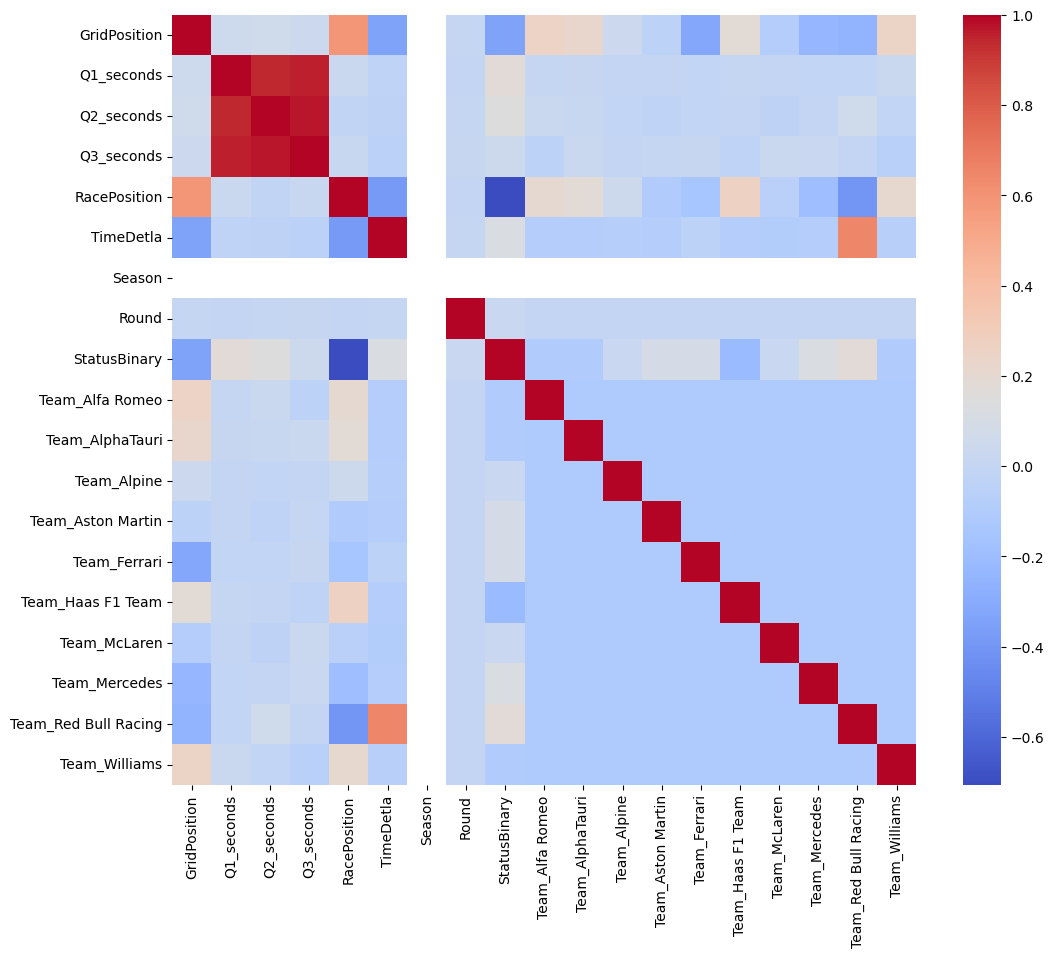

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/f1_2023.csv')

df["StatusBinary"] = df["Status"].eq("Finished").astype(int)

df_fin = df[df["Status"] == "Finished"].copy()

df = df.drop(columns = ['Time', 'Podium', 'Points', 'Status', 'DriverNumber'])



team_dummies = pd.get_dummies(df["TeamName"], prefix="Team")

df_numeric = pd.concat([df.drop(columns=['TeamName', 'FullName', 'EventName']), team_dummies], axis = 1)

df_numeric.head()

corr_matrix = df_numeric.corr()
print(corr_matrix)

plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.savefig('2023Races_Corr_Matrix.png')
